# Applications of Layout Algebra

This notebook walks through six key application patterns from Cecka,
*CuTe Layout Representation and Algebra* (arXiv:2603.02298v1),
showing how the algebra primitives compose to solve real GPU programming tasks.

**Context:** CuTe (CUDA Templates) is NVIDIA's C++ template library for writing
high-performance GPU kernels.  Its core abstraction is the *layout* — a pure
function from logical coordinates to memory offsets.  Layout algebra lets you
build complex data-distribution and tiling schemes by composing simple primitives,
rather than computing index arithmetic by hand.  This library is a pure-Python
implementation of that algebra, useful for understanding, prototyping, and
visualizing layouts before writing CUDA code.

The six sections build from simplest to most general:

1. **§3.3.4 Partitioning** — Thread-Value (TV) layouts: how CUDA threads divide up data
2. **§3.3.5 Tiling** — `logical_divide` splits data into tiles for multi-level GPU memory
3. **§3.4.2 Vectorization** — `upcast`/`downcast` convert bit↔element coordinates for wide loads
4. **§3.4.4 Admissibility** — checking whether operations are valid before applying them
5. **§3.5.1 Logical Product** — replicating a tile pattern across a larger space
6. **§3.5.2 Logical Divide** — the complement-based construction underlying divide and product

In [1]:
import warnings
warnings.filterwarnings("ignore", message="findfont")

In [2]:
from tensor_layouts import *
from tensor_layouts.viz import draw_layout, draw_tv_layout, draw_composite
from tensor_layouts.analysis import contiguity, mode_contiguity, slice_contiguity, explain

## §3.3.4 Partitioning — Thread-Value Layouts

In CUDA, a kernel launches many thread-blocks, each thread block threads that execute the same code in parallel.  When those threads need to cooperate on a shared data array, each thread must know **which elements it is responsible for**.  This can be 1:1 where a thread computes a single element in the thread-block, but more often than not, for efficiency reasons, a thread will compute multiple values.  CuTe encodes this assignment as a **TV (Thread-Value) layout** — a rank-2 `Layout(T, V)`:

- **Mode 0 — Thread (T):** maps a thread index `t ∈ [0, num_threads)` to a
  starting offset in the data array.  This is the *thread layout*.
- **Mode 1 — Value (V):** maps a value index `v ∈ [0, values_per_thread)` to the
  additional offsets each thread reads/writes.  This is computed as
  `complement(T, N)` — the set of offsets that `T` does *not* cover, which
  together with `T` tile the full array of size `N`.

The complete mapping is: **`offset = TV(t, v) = T(t) + V(v)`**.

Different choices of the thread layout `T` give different distribution patterns:

- **Blocked:** `T` has a large stride → threads own consecutive chunks
- **Striped:** `T` has stride 1 → threads own interleaved elements
- **Block-cyclic:** `T` has hierarchical shape → threads own scattered blocks

Thread layout T = 4 : 2
  offsets: [0, 2, 4, 6]

complement(T, 8) = 2 : 1
  value offsets: [0, 1]

TV layout = (4, 2) : (2, 1)

Thread-to-offset mapping:
  Thread 0: offsets [0, 1]
  Thread 1: offsets [2, 3]
  Thread 2: offsets [4, 5]
  Thread 3: offsets [6, 7]


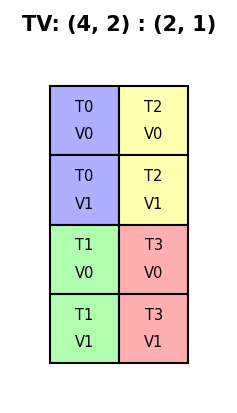

In [3]:
# Blocked TV layout — each thread owns consecutive elements
T = Layout(4, 2)
print(f"Thread layout T = {T}")
print(f"  offsets: {[T(i) for i in range(size(T))]}")

V = complement(T, 8)
print(f"\ncomplement(T, 8) = {V}")
print(f"  value offsets: {[V(i) for i in range(size(V))]}")

TV_blocked = Layout(T, V)
print(f"\nTV layout = {TV_blocked}")
print(f"\nThread-to-offset mapping:")
for t in range(size(T)):
    offsets = [TV_blocked(t, v) for v in range(size(V))]
    print(f"  Thread {t}: offsets {offsets}")

draw_tv_layout(TV_blocked, colorize=True)

Thread layout T = 4 : 1
  offsets: [0, 1, 2, 3]

complement(T, 8) = 2 : 4
  value offsets: [0, 4]

TV layout = (4, 2) : (1, 4)

Thread-to-offset mapping:
  Thread 0: offsets [0, 4]
  Thread 1: offsets [1, 5]
  Thread 2: offsets [2, 6]
  Thread 3: offsets [3, 7]


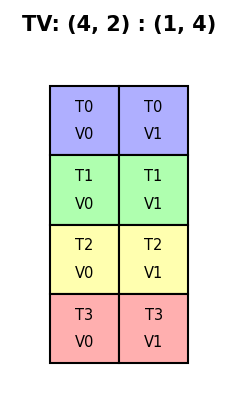

In [4]:
# Striped TV layout — each thread owns interleaved elements
T = Layout(4, 1)
print(f"Thread layout T = {T}")
print(f"  offsets: {[T(i) for i in range(size(T))]}")

V = complement(T, 8)
print(f"\ncomplement(T, 8) = {V}")
print(f"  value offsets: {[V(i) for i in range(size(V))]}")

TV_striped = Layout(T, V)
print(f"\nTV layout = {TV_striped}")
print(f"\nThread-to-offset mapping:")
for t in range(size(T)):
    offsets = [TV_striped(t, v) for v in range(size(V))]
    print(f"  Thread {t}: offsets {offsets}")

draw_tv_layout(TV_striped, colorize=True)

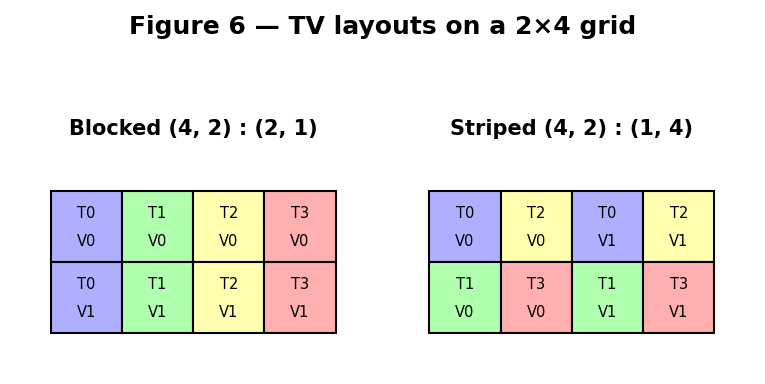

In [5]:
# Figure 6 — blocked vs striped on a 2×4 grid
draw_composite(
    [TV_blocked, TV_striped],
    titles=[f"Blocked {TV_blocked}", f"Striped {TV_striped}"],
    main_title="Figure 6 — TV layouts on a 2×4 grid",
    tv_mode=True,
    colorize=True,
    grid_rows=2, grid_cols=4,
)

### Table 4 — Common Distribution Patterns

The three canonical patterns differ only in how the thread layout `T` is strided.
All three distribute the same `T × V` elements across the same number of threads —
the choice depends on the memory access pattern the hardware prefers:

| Pattern | TV Layout | Thread stride | When to use |
|---|---|---|---|
| **Blocked** | `(T,V):(V,1)` | `V` (block size) | Maximizes per-thread locality |
| **Striped** | `(T,V):(1,T)` | `1` (consecutive) | Maximizes coalesced global memory access |
| **Block-cyclic** | `((B,T/B),V):((B,T·V/B),1)` | Hierarchical | Balances locality and coalescing |

For GPU **global memory**, striped patterns typically give the best coalescing
(adjacent threads access adjacent addresses, fitting in one memory transaction).
For **registers** or **shared memory**, blocked patterns are better because
each thread's data is contiguous, enabling vector loads.

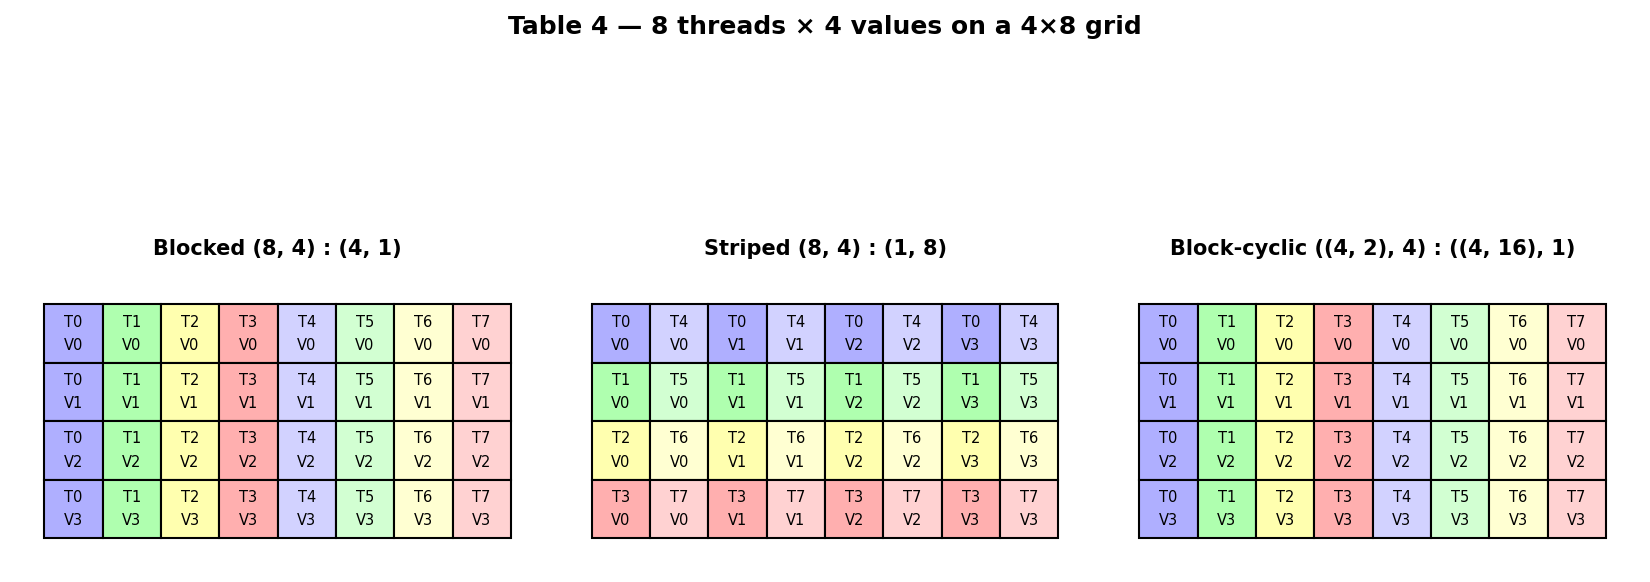

In [6]:
# Table 4 examples — 8 threads × 4 values = 32 elements
blocked     = Layout((8, 4), (4, 1))
striped     = Layout((8, 4), (1, 8))
block_cyclic = Layout(((4, 2), 4), ((4, 16), 1))

draw_composite(
    [blocked, striped, block_cyclic],
    titles=[f"Blocked {blocked}",
            f"Striped {striped}",
            f"Block-cyclic {block_cyclic}"],
    main_title="Table 4 — 8 threads × 4 values on a 4×8 grid",
    tv_mode=True,
    colorize=True,
    grid_rows=4, grid_cols=8,
)

## §3.3.5 Tiling

GPU kernels process data through multiple levels of the memory hierarchy:
**global memory → shared memory → registers**.  At each level, the data must be
**partitioned into tiles** that fit in the next-smaller storage.  For example,
a GEMM kernel tiles the output matrix into thread-block tiles (shared memory),
then sub-tiles each of those into per-thread fragments (registers).

`logical_divide(D, T)` is the universal tiling operation — it splits a data
layout `D` into tiles shaped like `T`:

- **Mode 0 (within-tile):** the coordinates inside a single tile
- **Mode 1 (across-tiles):** which tile you're in

The construction uses `complement` to find the residual (across-tile) coordinates:

```
logical_divide(D, T) = compose(D, Layout(T, complement(T, size(D))))
```

CuTe provides several variants that rearrange the same tiled result:

| Variant | Result structure | Use case |
|---|---|---|
| `logical_divide` | `((within₀, across₀), (within₁, across₁))` | Preserves per-mode hierarchy |
| `zipped_divide` | `((within₀, within₁), (across₀, across₁))` | Groups all within / all across |
| `tiled_divide` | `((within₀, within₁), across₀, across₁)` | Zipped + outer modes flattened |
| `flat_divide` | `(within₀, within₁, across₀, across₁)` | Fully flat — easiest to iterate |

D = 16 : 1
logical_divide(D, 4) = (4, 4) : (1, 4)
  mode 0 (within tile): size 4
  mode 1 (across tiles): size 4

logical_divide(16 : 1, 4 : 1)
  = compose(L, Layout(T, complement(T, size(L))))

  L = 16 : 1
  T = 4 : 1
  size(L) = 16
  complement(T, 16) = 4 : 4
  Layout(T, complement) = (4, 4) : (1, 4)
  compose(L, (4, 4) : (1, 4)) = (4, 4) : (1, 4)

  result = (4, 4) : (1, 4)


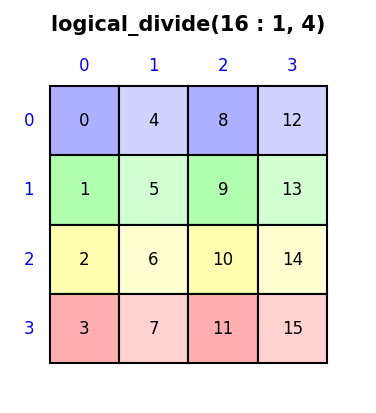

In [7]:
# 1D tiling: 16 elements into tiles of 4
D = Layout(16, 1)
result = logical_divide(D, 4)
print(f"D = {D}")
print(f"logical_divide(D, 4) = {result}")
print(f"  mode 0 (within tile): size {size(mode(result, 0))}")
print(f"  mode 1 (across tiles): size {size(mode(result, 1))}")
print()
explain(logical_divide, D, 4)

draw_layout(result, title=f"logical_divide({D}, 4)",
            colorize=True, flatten_hierarchical=False)

In [8]:
# 2D tiling: (4,8) row-major tiled by (2,4)
D = Layout((4, 8), (8, 1))
tiler = (2, 4)
print(f"D = {D}")
print(f"Tile by {tiler}\n")

ld = logical_divide(D, tiler)
zd = zipped_divide(D, tiler)
td = tiled_divide(D, tiler)
fd = flat_divide(D, tiler)

for name, r in [("logical_divide", ld), ("zipped_divide", zd),
                ("tiled_divide", td), ("flat_divide", fd)]:
    print(f"{name:16s} → shape={r.shape}  stride={r.stride}")

D = (4, 8) : (8, 1)
Tile by (2, 4)

logical_divide   → shape=((2, 2), (4, 2))  stride=((8, 16), (1, 4))
zipped_divide    → shape=((2, 4), (2, 2))  stride=((8, 1), (16, 4))
tiled_divide     → shape=((2, 4), 2, 2)  stride=((8, 1), 16, 4)
flat_divide      → shape=(2, 4, 2, 2)  stride=(8, 1, 16, 4)


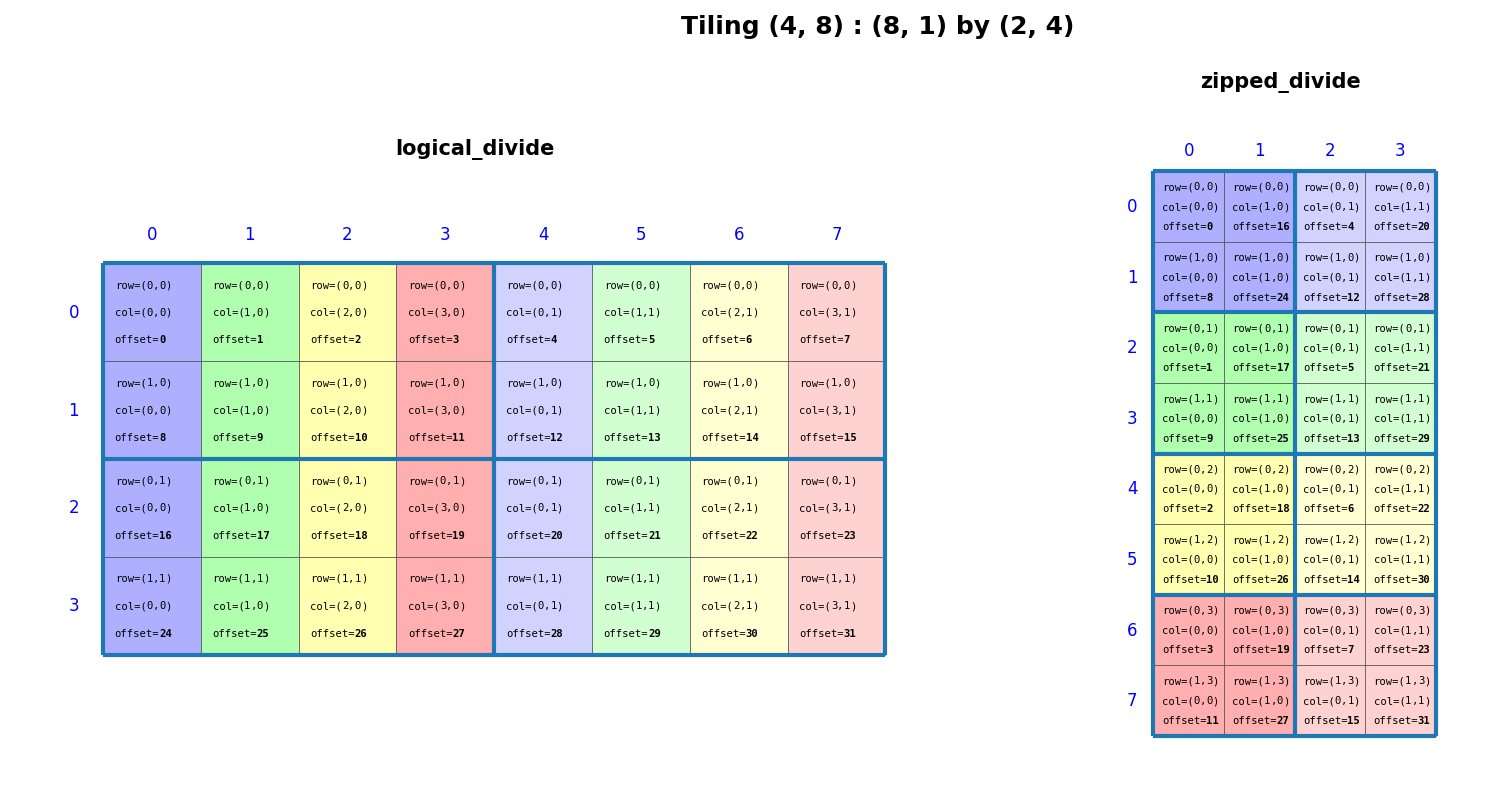

In [9]:
# Visualize the 2D tiling results
draw_composite(
    [(ld, {"flatten_hierarchical": False}),
     (zd, {"flatten_hierarchical": False})],
    titles=["logical_divide", "zipped_divide"],
    main_title=f"Tiling {D} by {tiler}",
    colorize=True,
)

Contiguous tile: logical_divide(16:1, 4)     = (4, 4) : (1, 4)
Strided tile:    logical_divide(16:1, 4:2)    = (4, (2, 2)) : (2, (1, 8))


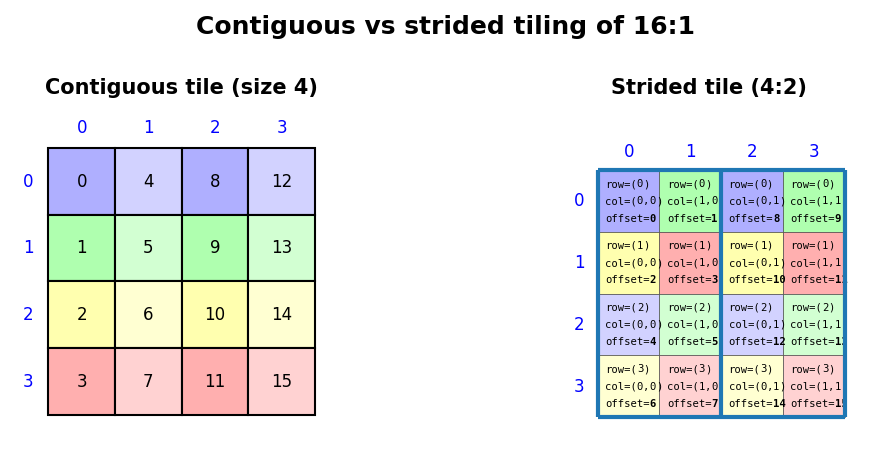

In [10]:
# Non-contiguous tiling: Layout tiler selects strided elements
contiguous_tile = logical_divide(Layout(16, 1), 4)
strided_tile = logical_divide(Layout(16, 1), Layout(4, 2))

print(f"Contiguous tile: logical_divide(16:1, 4)     = {contiguous_tile}")
print(f"Strided tile:    logical_divide(16:1, 4:2)    = {strided_tile}")

draw_composite(
    [(contiguous_tile, {"flatten_hierarchical": False}),
     (strided_tile, {"flatten_hierarchical": False})],
    titles=["Contiguous tile (size 4)", "Strided tile (4:2)"],
    main_title="Contiguous vs strided tiling of 16:1",
    colorize=True,
)

## §3.4.2 Vectorization

CUDA hardware can load or store multiple elements in a single transaction (e.g.,
`LDS.128` loads 128 bits at once — that's 8 × fp16 or 4 × fp32 elements).
To exploit this, CuTe internally represents memory layouts **in units of bits**,
then converts to typed element coordinates via `upcast` and `downcast`:

- **`upcast(bit_layout, n)`** — groups every `n` consecutive bits into one element.
  A layout mapping 32 bits per thread becomes 2 × fp16 elements per thread.
- **`downcast(elem_layout, n)`** — the inverse: expands each element back to `n` bits.

The **contiguity** of a layout — how many consecutive flat-index elements
starting from offset 0 are truly adjacent in memory — determines the maximum
vector width.  If `contiguity(L) = 4`, we can safely use 4-wide vector loads on `L`.

In [11]:
# upcast / downcast — bit ↔ element coordinate conversion
bits = Layout((32, 32), (32, 1))
print(f"Bit layout:     {bits}")
print(f"  32 threads × 32 bits each\n")

elems = upcast(bits, 16)
print(f"upcast(bits, 16) → fp16 elements: {elems}")
print(f"  32 threads × {size(mode(elems, 1))} elements each\n")

roundtrip = downcast(elems, 16)
print(f"downcast(elems, 16) → back to bits: {roundtrip}")
assert functionally_equal(roundtrip, bits), "Roundtrip failed!"
print("✓ Roundtrip verified")

Bit layout:     (32, 32) : (32, 1)
  32 threads × 32 bits each

upcast(bits, 16) → fp16 elements: (32, 2) : (2, 1)
  32 threads × 2 elements each

downcast(elems, 16) → back to bits: (32, 32) : (32, 1)
✓ Roundtrip verified


### Hierarchical upcast: LDMATRIX

NVIDIA's `LDMATRIX` instruction (Volta and later) loads matrix fragments from
shared memory directly into the register layout needed by Tensor Cores.  Each
warp's 32 threads cooperatively load multiple 32-bit groups (e.g., 4 × 32 bits =
128 bits per thread) from **non-contiguous** shared-memory locations.  The
resulting bit-layout is *hierarchical*: the inner mode covers 32 contiguous bits,
while the outer mode strides across matrix rows.  `upcast` handles this hierarchy
automatically, dividing only the inner contiguous mode by the element width.

In [12]:
# Hierarchical upcast (LDMATRIX-style: 4 groups of 32 bits per thread)
bits = Layout((32, (32, 4)), (32, (1, 1024)))
print(f"LDMATRIX bit layout: {bits}")
print(f"  32 threads × {size(mode(bits, 1))} bits per thread")
print(f"  = {size(mode(bits, 1)) // 16} fp16 elements per thread\n")

elems = upcast(bits, 16)
print(f"upcast(bits, 16) → {elems}")
print(f"  32 threads × {size(mode(elems, 1))} fp16 elements per thread")

LDMATRIX bit layout: (32, (32, 4)) : (32, (1, 1024))
  32 threads × 128 bits per thread
  = 8 fp16 elements per thread

upcast(bits, 16) → (32, (2, 4)) : (2, (1, 64))
  32 threads × 8 fp16 elements per thread


In [13]:
# Contiguity analysis — determines maximum vector width
layouts = [
    ("Contiguous 1D (16:1)",      Layout(16, 1)),
    ("Strided 1D (8:2)",          Layout(8, 2)),
    ("Col-major (4,8):(1,4)",     Layout((4, 8), (1, 4))),
    ("Row-major (4,8):(8,1)",     Layout((4, 8), (8, 1))),
    ("Gapped (4,4):(1,8)",        Layout((4, 4), (1, 8))),
]

print(f"{'Layout':30s}  contiguity  mode_contiguity")
print("-" * 65)
for name, L in layouts:
    c = contiguity(L)
    mc = mode_contiguity(L)
    print(f"{name:30s}  {c:10d}  {mc}")

print(f"\nSlice contiguity examples:")
L = Layout((4, 8), (1, 4))
print(f"  L = {L}")
print(f"  slice_contiguity(L, (0, None)) = {slice_contiguity(L, (0, None))}  (fix row=0, free cols)")
print(f"  slice_contiguity(L, (None, 0)) = {slice_contiguity(L, (None, 0))}  (free rows, fix col=0)")

Layout                          contiguity  mode_contiguity
-----------------------------------------------------------------
Contiguous 1D (16:1)                    16  [16]
Strided 1D (8:2)                         1  [1]
Col-major (4,8):(1,4)                   32  [4, 1]
Row-major (4,8):(8,1)                    1  [1, 8]
Gapped (4,4):(1,8)                       4  [4, 1]

Slice contiguity examples:
  L = (4, 8) : (1, 4)
  slice_contiguity(L, (0, None)) = 1  (fix row=0, free cols)
  slice_contiguity(L, (None, 0)) = 4  (free rows, fix col=0)


**Key insight:** `contiguity(L) = max_common_vector(L, Layout(size(L)))` —
it measures how well `L` agrees with the identity (contiguous) layout.
A contiguity of `k` means we can safely issue `k`-wide vector loads/stores.

Note the **column-major convention**: CuTe always iterates coordinates with
mode 0 (the leftmost) varying fastest, like Fortran/MATLAB.  So `Layout((4,8))`
auto-computes column-major strides `(1,4)`, giving contiguity 32 (all elements
are consecutive).  The "row-major" layout `(4,8):(8,1)` has contiguity **1** because
mode 0 has stride 8 — successive flat indices jump by 8 in memory.  This doesn't
mean row-major is bad; it means you'd slice along mode 1 (`slice_contiguity` with
mode 0 fixed) to find the 8-wide contiguous runs there.

## §3.4.4 Admissibility

Not every tiler works with every layout, and not every pair of layouts can be
vectorized.  Before issuing a `copy(src, dst)`, CuTe determines how wide a
vector instruction to use.  Before applying `logical_divide(D, T)`, it verifies
that the tiler `T` is structurally compatible with `D`.

Three predicates gate these operations:

- **`max_common_vector(src, dst)`** — the longest contiguous prefix where `src`
  and `dst` agree on their offset mapping.  This is the vector width for a copy.
- **`compatible(A, B)`** — can shape `A` be regrouped into shape `B`?  Required
  when a tiler's shape must match the data's.
- **`weakly_congruent(A, B)`** — is `A`'s nesting profile no deeper than `B`'s?
  Ensures a hierarchical tiler doesn't assume structure the data doesn't have.

In [14]:
# max_common_layout and max_common_vector
#
# These determine how wide a vector instruction copy(src, dst) can use.
# They compare the offset-mapping of two layouts starting from flat index 0
# and return the longest contiguous prefix where both agree.

# Case 1: Identical layouts — full agreement
a = Layout(16, 1)
b = Layout(16, 1)
print(f"max_common_vector({a}, {b}) = {max_common_vector(a, b)}")
print(f"  → 16-wide vector loads/stores\n")

# Case 2: Different shapes, same mapping!
# (4,4):(1,4) has column-major strides → maps flat index i to offset i,
# exactly like 16:1.  CuTe sees through the shape difference.
a = Layout((4, 4), (1, 4))
b = Layout(16, 1)
mcl = max_common_layout(a, b)
mcv = max_common_vector(a, b)
print(f"max_common_layout({a}, {b}) = {mcl}")
print(f"max_common_vector({a}, {b}) = {mcv}")
print(f"  → (4,4):(1,4) IS the identity in column-major order!\n")

# Case 3: Transposed layouts — disagree at the very first step
# (4,4):(1,4) sends flat 1 → offset 1;  (4,4):(4,1) sends flat 1 → offset 4.
a = Layout((4, 4), (1, 4))
b = Layout((4, 4), (4, 1))
print(f"max_common_vector({a}, {b}) = {max_common_vector(a, b)}")
print(f"  → element-by-element copy required")

max_common_vector(16 : 1, 16 : 1) = 16
  → 16-wide vector loads/stores

max_common_layout((4, 4) : (1, 4), 16 : 1) = 16 : 1
max_common_vector((4, 4) : (1, 4), 16 : 1) = 16
  → (4,4):(1,4) IS the identity in column-major order!

max_common_vector((4, 4) : (1, 4), (4, 4) : (4, 1)) = 1
  → element-by-element copy required


In [15]:
# compatible() — shape compatibility for tiling
print("compatible((2, 2, 3), (4, 3)) =", compatible((2, 2, 3), (4, 3)))
print("  2×2 groups to 4 ✓\n")

print("compatible(12, (2, 2, 3))     =", compatible(12, (2, 2, 3)))
print("  scalar compatible with any decomposition ✓\n")

print("compatible((2, 2, 3), (5, 2)) =", compatible((2, 2, 3), (5, 2)))
print("  sizes don't match: 12 ≠ 10 ✗")

compatible((2, 2, 3), (4, 3)) = True
  2×2 groups to 4 ✓

compatible(12, (2, 2, 3))     = True
  scalar compatible with any decomposition ✓

compatible((2, 2, 3), (5, 2)) = False
  sizes don't match: 12 ≠ 10 ✗


In [16]:
# weakly_congruent() — hierarchical profile matching
print("weakly_congruent(6, (2, 3))           =", weakly_congruent(6, (2, 3)))
print("  scalar a matches any b structure ✓\n")

print("weakly_congruent((2, 3), 6)           =", weakly_congruent((2, 3), 6))
print("  tuple a needs corresponding structure in b ✗\n")

print("weakly_congruent((2, (3, 4)), (5, 6)) =", weakly_congruent((2, (3, 4)), (5, 6)))
print("  a's mode 1 is nested (3,4) but b's is flat 6 ✗")

weakly_congruent(6, (2, 3))           = True
  scalar a matches any b structure ✓

weakly_congruent((2, 3), 6)           = False
  tuple a needs corresponding structure in b ✗

weakly_congruent((2, (3, 4)), (5, 6)) = False
  a's mode 1 is nested (3,4) but b's is flat 6 ✗


**Putting it together:** When CuTe copies data between layouts, it calls
`max_common_vector(src, dst)` to choose the widest safe vector instruction.
Before tiling a layout, it checks `compatible` (do the sizes decompose
correctly?) and `weakly_congruent` (does the tiler's nesting match the
data's structure?).  These are the *type checks* of layout algebra — they
catch invalid compositions before they produce wrong results.

## §3.5.1 Logical Product

In GPU kernels, a common pattern is: define a small tile pattern (e.g., how
one thread accesses a 4-element fragment), then **replicate** it across a
larger space (e.g., across all warps in a thread block, or across all tiles in
shared memory).

`logical_product(A, B)` does exactly this — it places `size(B)` non-overlapping
copies of `A`'s pattern, using `complement` to find where each replica goes:

```
logical_product(A, B) = Layout(A, compose(complement(A, size(A) * cosize(B)), B))
```

`blocked_product` and `raked_product` are two common specializations:
- **`blocked_product(A, B)`** — replicas are placed in contiguous blocks:
  `[A₀ A₁ A₂ A₃ | A₀ A₁ A₂ A₃]`
- **`raked_product(A, B)`** — replicas are interleaved:
  `[A₀ A₀ | A₁ A₁ | A₂ A₂ | A₃ A₃]`

In [17]:
# Basic logical product
A = Layout(4, 1)
B = Layout(3, 1)
P = logical_product(A, B)
print(f"A = {A}")
print(f"B = {B}")
print(f"logical_product(A, B) = {P}\n")

_ = explain(logical_product, A, B)

print(f"\nVerification — offsets per replica:")
for b in range(size(B)):
    offsets = [P(a, b) for a in range(size(A))]
    print(f"  Replica {b}: {offsets}")

A = 4 : 1
B = 3 : 1
logical_product(A, B) = (4, 3) : (1, 4)

logical_product(4 : 1, 3 : 1)
  = Layout(A, compose(complement(A, size(A)*size(B)), B))

  A = 4 : 1
  B = 3 : 1
  size(A) * size(B) = 12
  complement(A, 12) = 3 : 4
  compose(complement, B) = 3 : 4
  Layout(A, 3 : 4) = (4, 3) : (1, 4)

  result = (4, 3) : (1, 4)

Verification — offsets per replica:
  Replica 0: [0, 1, 2, 3]
  Replica 1: [4, 5, 6, 7]
  Replica 2: [8, 9, 10, 11]


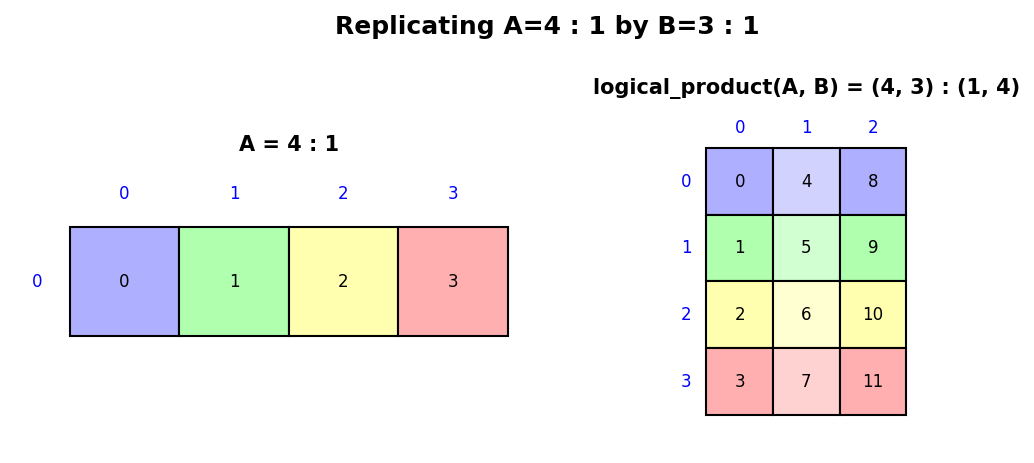

In [18]:
# Visualize the product
draw_composite(
    [A, P],
    titles=[f"A = {A}", f"logical_product(A, B) = {P}"],
    main_title=f"Replicating A={A} by B={B}",
    colorize=True,
)

blocked_product(4 : 1, 2 : 1) = ((4, 2),) : ((1, 4),)
  offsets: [0, 1, 2, 3, 4, 5, 6, 7]

raked_product(4 : 1, 2 : 1)   = ((2, 4),) : ((4, 1),)
  offsets: [0, 4, 1, 5, 2, 6, 3, 7]


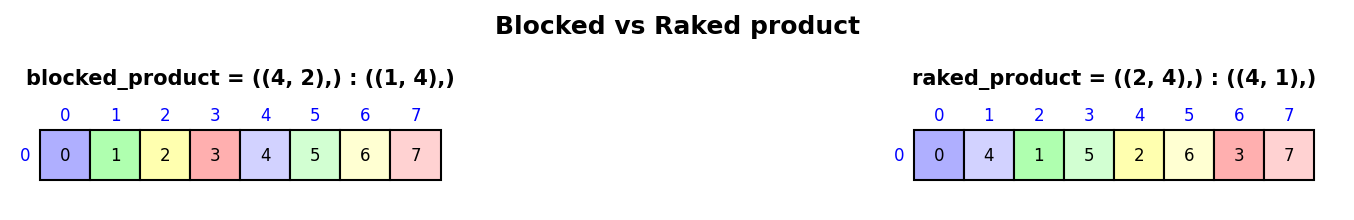

In [19]:
# blocked_product vs raked_product
A = Layout(4, 1)
B = Layout(2, 1)
bp = blocked_product(A, B)
rp = raked_product(A, B)

print(f"blocked_product({A}, {B}) = {bp}")
print(f"  offsets: {[bp(i) for i in range(size(bp))]}\n")
print(f"raked_product({A}, {B})   = {rp}")
print(f"  offsets: {[rp(i) for i in range(size(rp))]}")

draw_composite(
    [bp, rp],
    titles=[f"blocked_product = {bp}", f"raked_product = {rp}"],
    main_title="Blocked vs Raked product",
    colorize=True,
)

A = (2, 2) : (1, 2)  (2×2 tile)
B = (3, 4) : (1, 3)  (3×4 grid)
logical_product(A, B) = ((2, 2), (3, 4)) : ((1, 2), (4, 12))


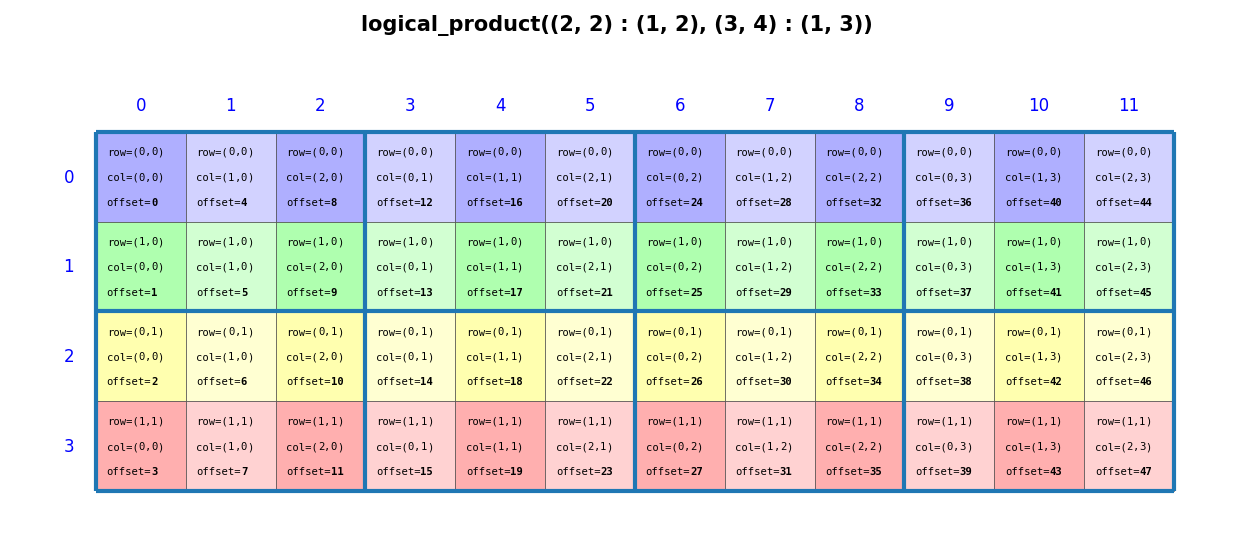

In [20]:
# 2D product — replicate a 2×2 tile across a 3×4 grid
A = Layout((2, 2), (1, 2))
B = Layout((3, 4), (1, 3))
P = logical_product(A, B)
print(f"A = {A}  (2×2 tile)")
print(f"B = {B}  (3×4 grid)")
print(f"logical_product(A, B) = {P}")

draw_layout(P, title=f"logical_product({A}, {B})",
            colorize=True, flatten_hierarchical=False)

## §3.5.2 Logical Divide — Complement-Based Construction

Divide and product are **duals**: both are built from `complement`, but they
compose it differently.  Understanding the shared construction makes the
entire algebra click:

```
logical_divide(A, T)  = compose(A, Layout(T, complement(T, size(A))))
                        ───────────────────────────────────────────
                        "Bundle T with its complement, then apply A"

logical_product(A, B) = Layout(A, compose(complement(A, size(A) * cosize(B)), B))
                        ─────────────────────────────────────────────────────────
                        "Find A's complement in a larger space, apply B to it"
```

In both cases, `complement` finds the "other" coordinates — the ones not covered
by the given layout.  **Divide** bundles a tiler with its complement to split data
into tiles; **product** maps a replication pattern onto the complement to place copies.

In [21]:
# Step-by-step logical_divide construction
A = Layout(16, 1)
T = Layout(4, 1)

C = complement(T, size(A))
print(f"A = {A}")
print(f"T = {T}")
print(f"complement(T, {size(A)}) = {C}\n")

bundled = Layout(T, C)
print(f"Layout(T, complement) = {bundled}")

result = compose(A, bundled)
print(f"compose(A, bundled)   = {result}\n")

expected = logical_divide(A, T)
print(f"logical_divide(A, T)  = {expected}")
assert functionally_equal(result, expected), "Construction mismatch!"
print("✓ Manual construction matches logical_divide\n")

_ = explain(logical_divide, A, T)

A = 16 : 1
T = 4 : 1
complement(T, 16) = 4 : 4

Layout(T, complement) = (4, 4) : (1, 4)
compose(A, bundled)   = (4, 4) : (1, 4)

logical_divide(A, T)  = (4, 4) : (1, 4)
✓ Manual construction matches logical_divide

logical_divide(16 : 1, 4 : 1)
  = compose(L, Layout(T, complement(T, size(L))))

  L = 16 : 1
  T = 4 : 1
  size(L) = 16
  complement(T, 16) = 4 : 4
  Layout(T, complement) = (4, 4) : (1, 4)
  compose(L, (4, 4) : (1, 4)) = (4, 4) : (1, 4)

  result = (4, 4) : (1, 4)


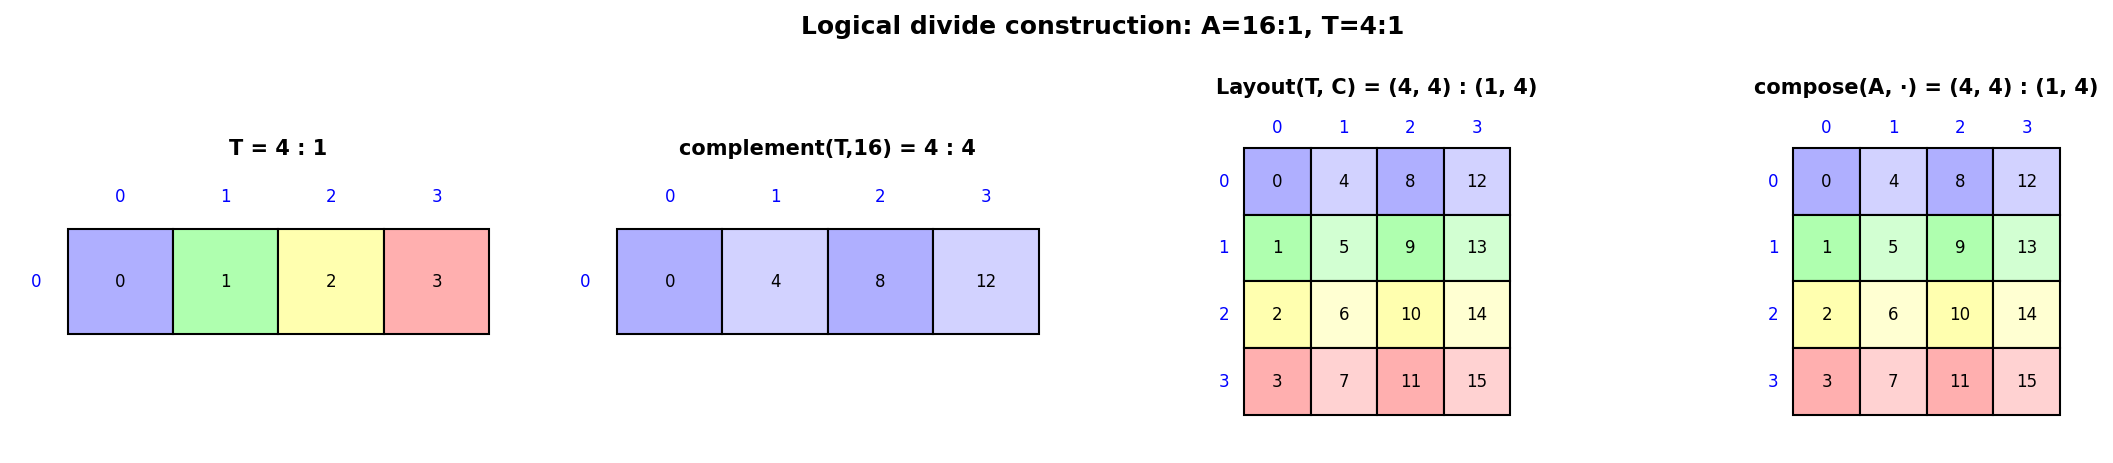

In [22]:
# Visualize the construction steps
draw_composite(
    [T, C, bundled, result],
    titles=[f"T = {T}", f"complement(T,16) = {C}",
            f"Layout(T, C) = {bundled}", f"compose(A, ·) = {result}"],
    main_title="Logical divide construction: A=16:1, T=4:1",
    colorize=True,
)

In [23]:
# Divide ↔ Product roundtrip
A = Layout(4, 1)
B = Layout(4, 1)

P = logical_product(A, B)
print(f"Start:   A = {A}")
print(f"Product: logical_product(A, {B}) = {P}")

D = logical_divide(P, A)
print(f"Divide:  logical_divide(P, A)    = {D}")
print(f"\nProduct produces {size(P)} elements in {size(B)} replicas of {size(A)}")
print(f"Divide recovers the tiled structure: {size(mode(D, 0))} within × {size(mode(D, 1))} across")

Start:   A = 4 : 1
Product: logical_product(A, 4 : 1) = (4, 4) : (1, 4)
Divide:  logical_divide(P, A)    = (4, 4) : (1, 4)

Product produces 16 elements in 4 replicas of 4
Divide recovers the tiled structure: 4 within × 4 across


## Summary

The six applications above all derive from the same small set of algebra primitives.
The unifying concept is **`complement`** — given a layout's coverage pattern,
find the residual coordinates that complete the index space:

| Application | Key Operation | What complement does |
|---|---|---|
| Partitioning (§3.3.4) | `Layout(T, complement(T, N))` | Finds per-thread values from thread layout |
| Tiling (§3.3.5) | `logical_divide(D, T)` | Finds across-tile coords from within-tile shape |
| Vectorization (§3.4.2) | `upcast`, `downcast`, `contiguity` | (Uses complement indirectly via `max_common_vector`) |
| Admissibility (§3.4.4) | `max_common_vector`, `compatible` | Measures shared contiguous structure |
| Logical Product (§3.5.1) | `logical_product(A, B)` | Finds non-overlapping placement for replicas |
| Logical Divide (§3.5.2) | `compose(A, Layout(T, complement(...)))` | Dual of product — partitions instead of replicating |

These operations compose naturally in a real GPU kernel:
1. **Partition** data across threads with a TV layout (§3.3.4)
2. **Tile** each thread's portion for shared memory and registers (§3.3.5)
3. **Vectorize** the innermost tile for wide loads/stores (§3.4.2)
4. **Check admissibility** before applying each transform (§3.4.4)
5. **Replicate** a small atom pattern to build larger tiles (§3.5.1)

This compositional approach — building complex GPU data layouts from simple,
verifiable algebraic primitives — is the core insight of CuTe.